# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

We're framing this as a regression problem, with price as the target variable. The goal is to model price as a function of features like mileage, make, model, year, and transmission type, and then use those results to understand which factors actually drive price, not just predict it accurately. That means our focus is on interpretability, examining the model's coefficients to see the direction and size of each feature's effect on price.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

In [31]:
cars_df = pd.read_csv('data/vehicles.csv')
cars_df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [32]:
cars_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

Looking at the output of `.info()`, the dataset contains 426,880 rows and 18 columns. Most columns are fairly complete, but a few have a significant number of missing values, most notably `size` (missing in about 72% of rows), `cylinders` (about 42% missing), and `condition` (about 41% missing). Other columns like `VIN`, `drive`, `type`, and `paint_color` are also missing anywhere from 20-40% of their values. These gaps will need to be addressed in the Data Preparation stage, likely by dropping columns with excessive missingness (like `size`) and deciding how to handle moderate missingness in the others.


In [33]:
cars_df.describe().apply(lambda x: x.apply('{:.2f}'.format))

,id,price,year,odometer
count,426880.00,426880.00,425675.00,422480.00
mean,7311486634.22,75199.03,2011.24,98043.33
std,4473170.41,12182282.17,9.45,213881.50
min,7207408119.00,0.00,1900.00,0.00
25%,7308143339.25,5900.00,2008.00,37704.00
50%,7312620821.00,13950.00,2013.00,85548.00
75%,7315253543.50,26485.75,2017.00,133542.50
max,7317101084.00,3736928711.00,2022.00,10000000.00


Running `.describe()` shows some pretty obvious data problems in the numeric columns. `Price` ranges from <span>$</span>0 all the way up to over <span>$</span>3.7 billion, and neither of those makes sense for a used car, so those are almost certainly bad entries or placeholders rather than real listings. Looking at the 25th and 75th percentiles (<span>$</span>5,900 and <span>$</span>26,486), it seems like most of the actual data sits in a much more normal range, so these extreme values are probably a small number of outliers rather than a widespread issue.

The `odometer` column has the same kind of problem, with a max of 10,000,000 miles, which obviously isn't realistic either. `Year` ranges from 1900 to 2022, which isn't necessarily wrong on its own since antique cars do get listed sometimes, but it is worth checking how many rows actually fall near that low end to see if it's a handful of real antiques or more likely a data entry issue.

Overall, these numeric columns are going to need some outlier filtering before we move into visualization or modeling, since leaving values like these in would throw off both the plots and the regression results later on.

Before jumping into data preparation, a few more visuals help paint a clearer picture of what's going on. First up is the `price` distribution on its own, then two relationships worth checking out: `price` vs. `odometer`, and `price` vs. `year`. Both `odometer` and `year` seem like they'd be closely tied to `price`, so it's worth looking at these early on.

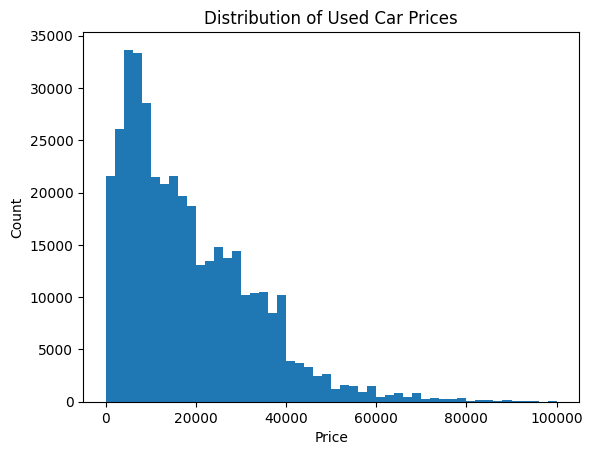

In [34]:
# visualizing the price column
cars_df_viz = cars_df[(cars_df['price'] > 0) & (cars_df['price'] < 100000)]

plt.hist(cars_df_viz['price'], bins=50)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Distribution of Used Car Prices')
plt.show()

This chart shows the distribution of price after filtering out the extreme outliers identified earlier. It's clearly right-skewed, most listings are priced between <span>$</span>5,000 and <span>$</span>10,000, and the count drops off steadily from there, with a long tail stretching out toward <span>$</span>100,000 for a smaller number of higher-priced vehicles.

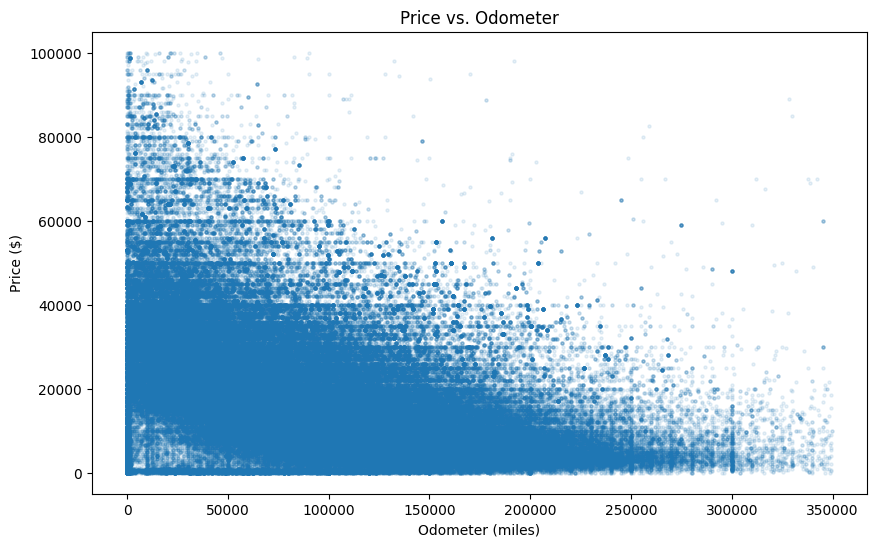

In [35]:
# visualizing price vs. odometer
cars_df_viz2 = cars_df[(cars_df['price'] > 0) & (cars_df['price'] < 100000) & (cars_df['odometer'] < 350000)]

plt.figure(figsize=(10, 6))
plt.scatter(cars_df_viz2['odometer'], cars_df_viz2['price'], alpha=0.1, s=5)
plt.xlabel('Odometer (miles)')
plt.ylabel('Price ($)')
plt.title('Price vs. Odometer')
plt.show()

This chart shows a clear negative relationship between `odometer` and `price`, as mileage goes up, the price tends to go down. The highest-priced cars are mostly clustered at lower mileage, and the cloud of points thins out and drops toward the bottom right as mileage increases. This lines up with what would be expected, more miles usually means more wear on a car, so it makes sense that buyers are willing to pay less for it.

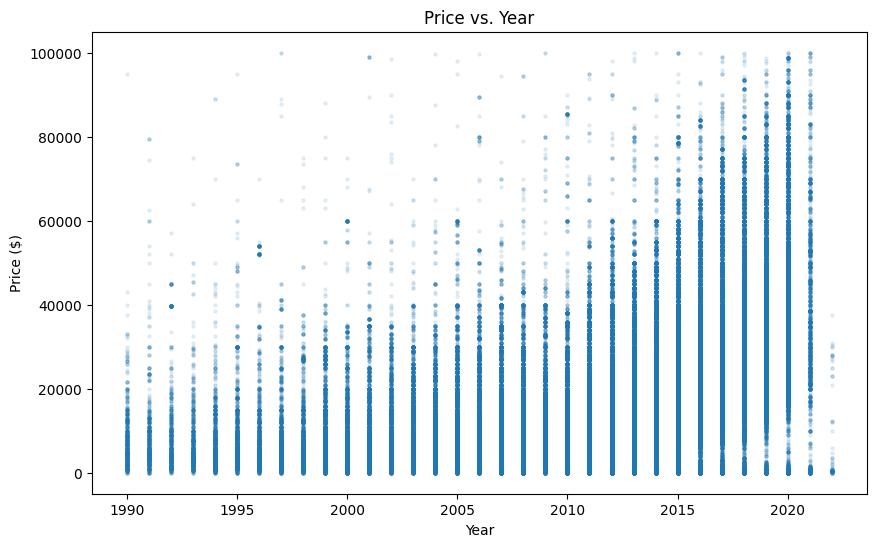

In [36]:
cars_df_viz3 = cars_df[(cars_df['price'] > 0) & (cars_df['price'] < 100000) & (cars_df['year'] >= 1990)]

plt.figure(figsize=(10, 6))
plt.scatter(cars_df_viz3['year'], cars_df_viz3['price'], alpha=0.1, s=5)
plt.xlabel('Year')
plt.ylabel('Price ($)')
plt.title('Price vs. Year')
plt.show()

This chart makes it pretty clear that `price` and `year` go up together, newer cars (further right) tend to sell for more, and the spread toward higher prices really widens out after around 2015. That said, there are still plenty of cheap listings across every year, which makes sense since price isn't just about how new a car is, factors like mileage, condition, and vehicle type all play a role too.

So far we've only looked at price alongside `odometer` and `year`, the two continuous variables. But a few of the categorical columns, especially `type`, `fuel`, and `condition`, seem just as likely to matter, so let's take a quick look at those before moving into Data Preparation.

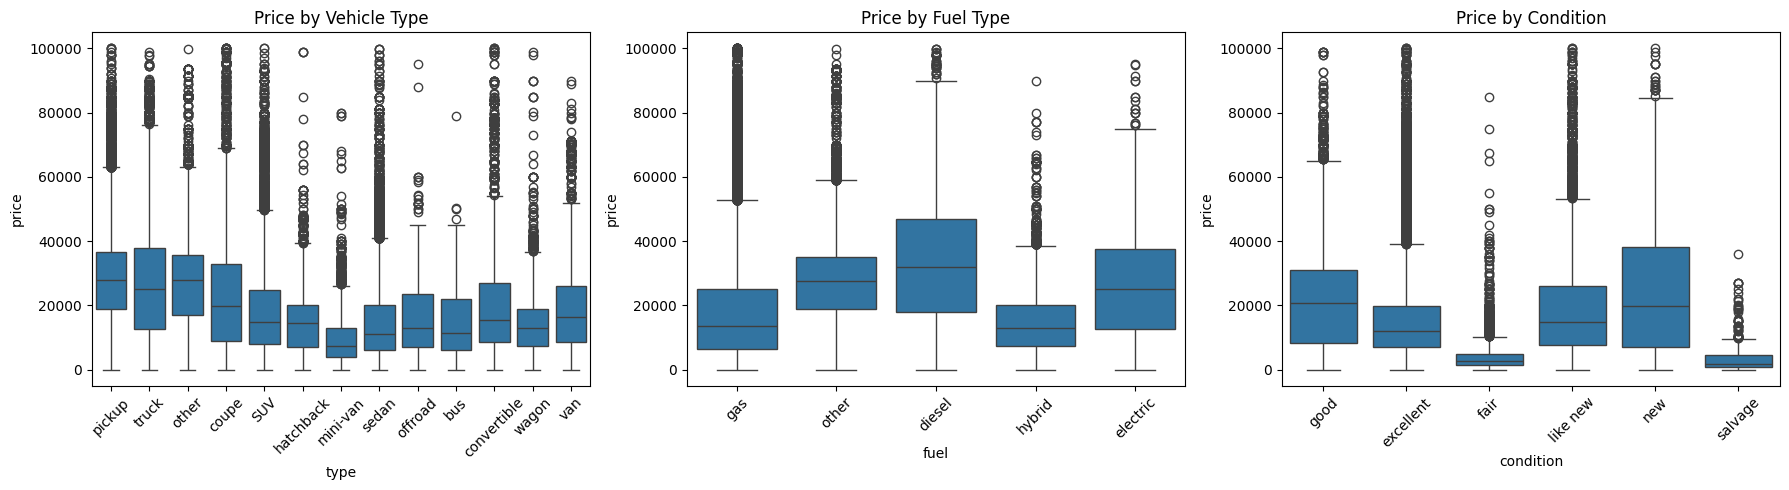

In [37]:
# visualizing price by key categorical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=cars_df_viz, x='type', y='price', ax=axes[0])
axes[0].set_title('Price by Vehicle Type')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=cars_df_viz, x='fuel', y='price', ax=axes[1])
axes[1].set_title('Price by Fuel Type')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=cars_df_viz, x='condition', y='price', ax=axes[2])
axes[2].set_title('Price by Condition')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

`Type` shows the clearest separation, pickups and trucks command higher prices than sedans, hatchbacks, or minivans. For `fuel`, diesel and electric both price notably higher than gas or hybrid, probably because diesel tends to show up in bigger trucks and electric tends to show up in newer, pricier vehicles. `Condition` is messier. "New" and "like new" trend higher like you'd expect, but "good" and "excellent" overlap a lot and don't separate nearly as cleanly as type or fuel do.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

Before filtering the data, reasonable cutoffs need to be decided for the `price` column.

In [9]:
# checking percentiles
print(cars_df['price'].quantile([0.01, 0.05, 0.95, 0.99]))

0.01        0.0
0.05        0.0
0.95    44500.0
0.99    66995.0
Name: price, dtype: float64


Looking at the `price` percentiles, the 1st and 5th percentiles are both <span>$</span>0, which suggests that at least 5% of listings have a `price` of <span>$</span>0 and are unlikely to represent real sales. On the other end, the 95th percentile is <span>$</span>44,500 and the 99th is <span>$</span>66,995, meaning the vast majority of real listings fall well below <span>$</span>70,000. Based on this, we are filtering the dataset to only include listings priced between <span>$</span>500 and <span>$</span>200,000. This removes the <span>$</span>0 entries and other unrealistically low prices while still keeping a wide margin above the 99th percentile, so legitimate high-end vehicles aren't excluded, but extreme outliers like the <span>$</span>3.7 billion entry are removed.

In [10]:
# dropping entries between 500 and 200,000
cars_df = cars_df[(cars_df['price'] >= 500) & (cars_df['price'] <= 200000)] 

cars_df.describe()

,id,price,year,odometer
count,3.846620e+05,384662.000000,383489.000000,3.825400e+05
mean,7.311466e+09,19312.899587,2010.972030,9.851708e+04
std,4.477570e+06,14990.206166,9.601722,1.920005e+05
min,7.207408e+09,500.000000,1900.000000,0.000000e+00
25%,7.308083e+09,7800.000000,2008.000000,3.818425e+04
50%,7.312586e+09,15900.000000,2013.000000,8.768400e+04
75%,7.315244e+09,27990.000000,2017.000000,1.360000e+05
max,7.317101e+09,200000.000000,2022.000000,1.000000e+07


Now, we do the same for the `odometer` column.

In [11]:
# checking percentiles
print(cars_df['odometer'].quantile([0.01, 0.05, 0.95, 0.99]))

0.01        21.0
0.05      7012.0
0.95    206000.0
0.99    280000.0
Name: odometer, dtype: float64


Odometer percentiles look reasonable up through the 99th percentile (280,000 miles), so no lower cutoff is needed. However, the max value of 10,000,000 miles is clearly an error. Filtering out anything above 350,000 miles removes these unrealistic entries while still keeping legitimate high-mileage vehicles.

In [12]:
# filtering out entries higher than 350,000
cars_df = cars_df[cars_df['odometer'] <= 350000]

cars_df['odometer'].describe()

count    380707.000000
mean      92263.935026
std       62896.685823
min           0.000000
25%       38000.000000
50%       87072.000000
75%      135113.000000
max      350000.000000
Name: odometer, dtype: float64

Now that the `price` and `odometer` columns have been filtered for unrealistic values, the next step is to work through the many missing values in the rest of the dataset. Rather than dropping any row with a missing value, missing data is handled on a column-by-column basis, since dropping every row with at least one gap would end up removing way too much of the dataset given how many columns have missing values. 

We can drop the `id` and `VIN` columns entirely since they're just identifiers and don't actually help predict price. `Size` is also dropped, since it's missing in about 72% of rows, which is too much to fill in without basically making up most of the column. 

For the other categorical columns with a moderate amount of missing data (`condition`, `cylinders`, `drive`, `type`, and `paint_color`), missing values are filled in with `"unknown"` instead of dropping those rows. This keeps more of the data and treats missingness as its own category, which might even carry some useful signal, since certain sellers may be more or less likely to fill in these fields. 

For the columns that are only missing a small number of values (`year`, `manufacturer`, `model`, `fuel`, `odometer`, `title_status`, and `transmission`), those rows are just dropped since it only affects a small portion of the dataset.

In [13]:
# dropping identifier columns and the size column
cars_df = cars_df.drop(columns=['id', 'VIN', 'size'])

# filling moderate-missingness categorical columns with "unknown"
fill_unknown_cols = ['condition', 'cylinders', 'drive', 'type', 'paint_color']
cars_df[fill_unknown_cols] = cars_df[fill_unknown_cols].fillna('unknown')

# dropping rows with missing values in the small-missingness columns
small_missing_cols = ['year', 'manufacturer', 'model', 'fuel', 'odometer', 'title_status', 'transmission']
cars_df = cars_df.dropna(subset=small_missing_cols)

In [14]:
# checking non-null count
cars_df.info()

<class 'pandas.DataFrame'>
Index: 352293 entries, 27 to 426879
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        352293 non-null  str    
 1   price         352293 non-null  int64  
 2   year          352293 non-null  float64
 3   manufacturer  352293 non-null  str    
 4   model         352293 non-null  str    
 5   condition     352293 non-null  str    
 6   cylinders     352293 non-null  str    
 7   fuel          352293 non-null  str    
 8   odometer      352293 non-null  float64
 9   title_status  352293 non-null  str    
 10  transmission  352293 non-null  str    
 11  drive         352293 non-null  str    
 12  type          352293 non-null  str    
 13  paint_color   352293 non-null  str    
 14  state         352293 non-null  str    
dtypes: float64(2), int64(1), str(12)
memory usage: 43.0 MB


After filtering out unrealistic `price` and `odometer` values and handling missing data across the rest of the columns, the dataset went from 426,880 rows and 18 columns down to 352,293 rows and 15 columns. This is about a 17.5% reduction in rows, which is a reasonable tradeoff. Most of the data is preserved while removing the entries that were clearly bad or unusable for analysis.

We now check for duplicate rows.

In [15]:
# checking for how many rows are duplicates
print(f"Number of duplicate rows: {cars_df.duplicated().sum()}")

Number of duplicate rows: 42138


In [16]:
# dropping duplicated rows
cars_df = cars_df.drop_duplicates()
print(f"Rows remaining after dropping duplicates: {len(cars_df)}")

Rows remaining after dropping duplicates: 310155


The dataset contained 42,138 exact duplicate rows, likely from listings being reposted or scraped more than once when the data was originally collected. These duplicates are removed since they could influence the model by essentially counting the same car and price multiple times, rather than reflecting genuinely unique data points.

Finally, the cardinality of the categorical columns is checked. Since regression requires numerical input, categorical columns need to either be low cardinality enough to encode numerically, or handled separately if they have too many unique values to encode effectively.

In [17]:
for col in cars_df.select_dtypes(include='str').columns:
    print(f"{col}: {cars_df[col].nunique()} unique values")

region: 404 unique values
manufacturer: 41 unique values
model: 20224 unique values
condition: 7 unique values
cylinders: 9 unique values
fuel: 5 unique values
title_status: 6 unique values
transmission: 3 unique values
drive: 4 unique values
type: 14 unique values
paint_color: 13 unique values
state: 51 unique values


Most columns have a manageable number of categories, ranging from 3 to 51, which is reasonable to one-hot encode. `Region` (404 unique values) and `model` (20,224 unique values) are the exceptions, encoding either would create thousands of mostly empty columns and add noise rather than signal. `Region` is dropped since `state` already captures location, and `model` is dropped since `manufacturer` already captures vehicle type without sacrificing interpretability.

In [18]:
cars_df = cars_df.drop(columns=['region', 'model'])
cars_df.info()

<class 'pandas.DataFrame'>
Index: 310155 entries, 27 to 426879
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         310155 non-null  int64  
 1   year          310155 non-null  float64
 2   manufacturer  310155 non-null  str    
 3   condition     310155 non-null  str    
 4   cylinders     310155 non-null  str    
 5   fuel          310155 non-null  str    
 6   odometer      310155 non-null  float64
 7   title_status  310155 non-null  str    
 8   transmission  310155 non-null  str    
 9   drive         310155 non-null  str    
 10  type          310155 non-null  str    
 11  paint_color   310155 non-null  str    
 12  state         310155 non-null  str    
dtypes: float64(2), int64(1), str(10)
memory usage: 33.1 MB


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

To start off the modeling section, the remaining categorical columns that weren't removed in the previous section are one-hot encoded. We can use pandas' `get_dummies` function for this.



In [19]:
cars_encoded = pd.get_dummies(cars_df, columns=[
    'manufacturer', 'condition', 'cylinders', 'fuel',
    'title_status', 'transmission', 'drive', 'type',
    'paint_color', 'state'
], drop_first=True)

cars_encoded.info()

<class 'pandas.DataFrame'>
Index: 310155 entries, 27 to 426879
Columns: 146 entries, price to state_wy
dtypes: bool(143), float64(2), int64(1)
memory usage: 51.8 MB


Note: since `drop_first=True` was used, one category per column is dropped and becomes the main reference category that all other categories in that column are compared against. For example, `diesel` was dropped from `fuel`, and `4wd` was dropped from `drive`.

Before fitting a model, the data needs to be split into a training set and a test set. This is so the model can be evaluated on data it hasn't seen during training, which gives a more honest picture of how well it would perform on new listings rather than just how well it memorized the data it was trained on.

In [20]:
# running a train/test split
X = cars_encoded.drop(columns=['price'])
y = cars_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (248124, 145)
Test set: (62031, 145)


With the data split into training and test sets, a baseline linear regression model can now be fit. This provides a starting point for understanding how well price can be predicted from the available features, and sets up a comparison point for the more refined models used later, such as LASSO.

Note that MAE and RMSE are used to check how well the model's price predictions match actual prices. MAE gives the average dollar amount predictions are off by, which is simple to explain to a dealership audience. RMSE is included too since it penalizes bigger mistakes more, which matters here since a few cars are priced much higher than most others, even after removing extreme outliers.

In [21]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 6099.90
RMSE: 9140.11


The baseline linear regression model has an MAE of about <span>$</span>6,100 and an RMSE of about <span>$</span>9,140. Since RMSE is noticeably higher than MAE, this means some predictions are way off, more than just a typical case. Given that most cars in the dataset are priced somewhere between <span>$</span>5,900 and <span>$</span>26,500, being off by <span>$</span>6,100 on average is a pretty big error. This makes sense though, since this is just a first, basic model with no scaling or feature selection applied yet. Let's try applying LASSO and seeing if the results improve.

In [22]:
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0, max_iter=10000))
])

lasso_pipe.fit(X_train, y_train)

y_pred_lasso = lasso_pipe.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = root_mean_squared_error(y_test, y_pred_lasso)

print(f"Lasso MAE: {mae_lasso:.2f}")
print(f"Lasso RMSE: {rmse_lasso:.2f}")

Lasso MAE: 6009.22
Lasso RMSE: 8970.49


The previous LASSO model used a base alpha of `1.0`. `GridSearchCV` is used here to search across several alpha values and find the one that performs best.

In [23]:
param_grid = {
    'lasso__alpha': [0.1, 1, 10]
}

grid_search = GridSearchCV(
    lasso_pipe,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best alpha: {grid_search.best_params_}")

Best alpha: {'lasso__alpha': 0.1}


In [24]:
# lasso using best alpha
best_lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1, max_iter=10000))
])

best_lasso_pipe.fit(X_train, y_train)

y_pred_best_lasso = best_lasso_pipe.predict(X_test)

mae_best_lasso = mean_absolute_error(y_test, y_pred_best_lasso)
rmse_best_lasso = root_mean_squared_error(y_test, y_pred_best_lasso)

print(f"Tuned Lasso MAE: {mae_best_lasso:.2f}")
print(f"Tuned Lasso RMSE: {rmse_best_lasso:.2f}")

Tuned Lasso MAE: 6009.17
Tuned Lasso RMSE: 8969.90


To find the best regularization strength for LASSO, a grid search was performed over several alpha values using 3-fold cross-validation. The best alpha found was `0.1`, compared to the original choice of `1.0`. Refitting LASSO with this tuned alpha resulted in only a small improvement (MAE of <span>$</span>6,009.17 vs. <span>$</span>6,009.22, RMSE of <span>$</span>8,969.90 vs. <span>$</span>8,970.49), suggesting that LASSO's performance on this dataset isn't very sensitive to the choice of alpha within this range.

Even with an optimized alpha value, LASSO only offered a small improvement over the untuned version, and only a modest improvement over the baseline linear regression model overall. It also isn't the easiest to explain or work with, since it picks features by shrinking some coefficients all the way to zero. `Sequential Feature Selector` is used instead, since it builds up the feature set one at a time, testing each addition based on how much it actually improves the model, which makes it easier to see exactly which features are pulling their weight.

In [25]:
sfs = SequentialFeatureSelector(
    lr,
    n_features_to_select=15,
    direction='forward',
    scoring='neg_mean_squared_error',
    cv=5
)

sfs.fit(X_train, y_train)

selected_features = X_train.columns[sfs.get_support()]
print(selected_features)

Index(['year', 'odometer', 'manufacturer_nissan', 'condition_unknown',
       'cylinders_4 cylinders', 'cylinders_8 cylinders', 'fuel_gas',
       'fuel_hybrid', 'fuel_other', 'drive_fwd', 'drive_unknown', 'type_coupe',
       'type_other', 'type_pickup', 'type_truck'],
      dtype='str')


Now that `Sequential Feature Selector` has narrowed the features down to 15, a linear regression model is fit using just this smaller feature set. This makes it possible to see how well a much simpler, more interpretable model performs compared to the baseline and LASSO models.

In [26]:
X_train_sfs = X_train[selected_features]
X_test_sfs = X_test[selected_features]

lr_sfs = LinearRegression()
lr_sfs.fit(X_train_sfs, y_train)

y_pred_sfs = lr_sfs.predict(X_test_sfs)

mae_sfs = mean_absolute_error(y_test, y_pred_sfs)
rmse_sfs = root_mean_squared_error(y_test, y_pred_sfs)

print(f"SFS MAE: {mae_sfs:.2f}")
print(f"SFS RMSE: {rmse_sfs:.2f}")

SFS MAE: 6460.55
SFS RMSE: 9543.94


Comparing all three models, the SFS model with just 15 features performs slightly worse than both the full linear regression and LASSO models (MAE of <span>$</span>6,460 vs. <span>$</span>6,099 and <span>$</span>6,009, RMSE of <span>$</span>9,544 vs. <span>$</span>9,140 and <span>$</span>8,970). This is expected, since SFS is using far fewer features to work with.

Now, let's extract the coefficients and their effect.

In [27]:
sfs_coef_df = pd.DataFrame({
    'feature': selected_features,
    'coefficient': lr_sfs.coef_
}).sort_values('coefficient', ascending=False)


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

Going back to the original business objective, the goal was to identify what factors drive used car prices in order to give the dealership meaningful, actionable insight, not necessarily to build the most accurate predictive model possible. With that in mind, the SFS model's slightly lower performance compared to LASSO and the baseline is an acceptable tradeoff, since it offers a much clearer, more interpretable picture of what's actually driving price.

In [38]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'LASSO', 'SFS (15 features)'],
    'MAE': [mae, mae_lasso, mae_sfs],
    'RMSE': [rmse, rmse_lasso, rmse_sfs]
})
comparison_df

,Model,MAE,RMSE
0,Linear Regression,6099.895736,9140.105442
1,LASSO,6009.221392,8970.493309
2,SFS (15 features),6460.554120,9543.940980


Now that the three models have been compared, the next step is to dig into what the SFS model actually found. Looking at its coefficients shows which features had the strongest effect on price, and gives a clearer picture of what's actually driving pricing decisions in this dataset.

Despite the slightly lower performance, the drop is fairly small given how much simpler the SFS model is, going from 145 features down to just 15. This suggests that a small set of features, like `year`, `odometer`, `cylinder count`, `drive type`, `fuel type`, and `vehicle type`, can explain most of what drives `price`, which makes for a much easier story to tell a dealership client than a model with 145 coefficients.

Before looking at the coefficients themselves, it's worth noting how the categorical features were encoded. Since `drop_first=True` was used earlier, each categorical column has one category left out as a reference, and every other category's coefficient represents a price difference compared to that reference. For the features selected by SFS, this means `fuel_gas`, `fuel_hybrid`, and `fuel_other` are all compared against diesel, `drive_fwd` and `drive_unknown` are compared against 4WD, and the vehicle type features are compared against SUVs. With that in mind, the chart below shows the effect of each feature on price relative to its reference category.

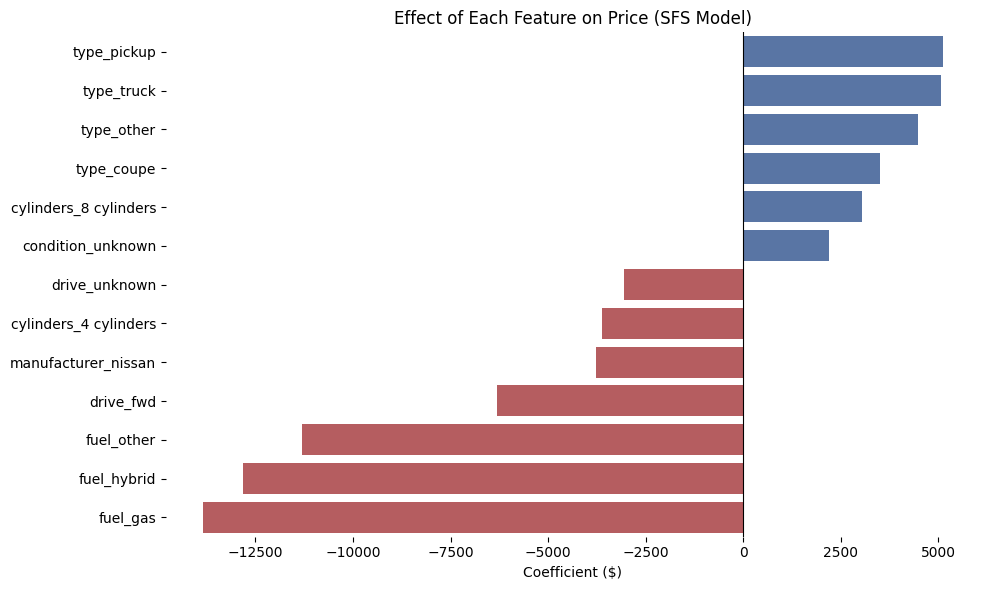

In [29]:
# seperating continuous vs categorical features for cleaner visualization
categorical_coef_df = sfs_coef_df[~sfs_coef_df['feature'].isin(['year', 'odometer'])]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=categorical_coef_df,
    x='coefficient',
    y='feature',
    hue=categorical_coef_df['coefficient'] > 0,
    dodge=False,
    palette={True: '#4C72B0', False: '#C44E52'},
    legend=False
)
plt.xlabel('Coefficient ($)')
plt.ylabel('')
plt.title('Effect of Each Feature on Price (SFS Model)')
plt.axvline(0, color='black', linewidth=0.8)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

This plot shows that vehicle type and fuel type have the strongest effect on price. Pickup trucks and trucks in general sell for roughly <span>$</span>5,000 more than a comparable SUV, and vehicles with 8 cylinders add about <span>$</span>3,000 over the reference cylinder count (10). On the other end, gas-powered vehicles are priced about <span>$</span>13,800 lower than a comparable diesel vehicle, likely because diesel engines are more common in larger, higher-value trucks. Front-wheel drive vehicles are also priced notably lower, about <span>$</span>6,300 less than a comparable 4WD vehicle.

There are a few limitations worth keeping in mind. The `model` and `region` columns were dropped early on due to high cardinality, which means this analysis can't speak to specific car models or specific regional markets, only broader manufacturer and state patterns. 

The `condition_unknown` result was also a bit counterintuitive, since listings missing a reported condition were priced higher rather than lower, which is more likely a quirk in the data than a real pricing pattern. 

Similarly, categories like `type_other` and `fuel_other` are vague catch-alls that combine unrelated vehicles, making them harder to translate into concrete advice. It's also worth noting that this dataset only reflects Craigslist listings, so the findings may not generalize perfectly to other marketplaces or to the dealership's specific regional market. 

Finally, since this is a regression model built for inference, the coefficients show association between features and price, not proof that changing one of these features would directly cause a price change.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

This analysis looked at hundreds of thousands of used car listings to understand which features are most closely tied to higher prices, with the goal of helping guide inventory decisions.

`Vehicle type` turned out to be one of the strongest factors. Pickup trucks and trucks in general consistently sold for more than other body styles, roughly <span>$</span>5,000 more on average than a comparable SUV. Used car dealers interested in fine-tuning their inventory should prioritize stocking trucks.

`Fuel type` also stood out, with diesel-powered vehicles priced notably higher than gas, hybrid, or other fuel types, often by <span>$</span>10,000 or more. This is likely tied to diesel's association with larger, heavy-duty trucks, but it's still a pattern worth factoring into pricing decisions. Along similar lines, vehicles with four-wheel drive and larger, 8-cylinder engines tended to sell for more than front-wheel drive or smaller-engine vehicles, suggesting these features are worth highlighting when marketing inventory.

As expected, newer and lower-mileage vehicles remained reliable value drivers, with a clear, consistent relationship between `year`, `mileage`, and `price`. This lines up with the `price` vs. `year` and `price` vs. `odometer` scatterplots explored earlier, both showed the same trends visually before the model confirmed them numerically. This isn't surprising, but it reinforces that these two factors should stay a top priority during acquisition. One less expected finding was that reported vehicle condition didn't show a clear or trustworthy pricing pattern in this dataset, suggesting it may not be a strong standalone factor to lean on for pricing decisions without further investigation.

Overall, the data suggests that trucks, diesel engines, four-wheel drive, and newer, lower-mileage vehicles consistently commanded higher prices. Dealerships looking to maximize resale value may want to prioritize sourcing inventory with these characteristics. As far as next steps go, since `model` and `region` were dropped here due to high cardinality, it would be interesting to group rare models into an "other" bucket and include that in the analysis instead of dropping the column entirely. It's also worth digging deeper into the `condition_unknown` category, since its higher than expected pricing pattern doesn't have an obvious explanation yet.